# Customer Churn Analysis

## Project Objective

This notebook analyzes 7,043 telecommunications customers to identify
customer characteristics, service patterns, and financial factors associated
with churn.

In [1]:
import pandas as pd
from sqlalchemy import create_engine, URL
from getpass import getpass

## 1. Database Connection

Connect to the MySQL database using SQLAlchemy. The password is entered
securely and is not stored inside the notebook.

In [2]:
mysql_password = getpass("Enter your MySQL password: ")

connection_url = URL.create(
    drivername="mysql+pymysql",
    username="root",
    password=mysql_password,
    host="localhost",
    port=3306,
    database="customer_churn_analysis"
)

engine = create_engine(connection_url)

Enter your MySQL password:  ········


## 2. Data Loading

Load the combined `customer_churn_master` SQL view into a pandas DataFrame.

In [3]:
query = """
SELECT *
FROM customer_churn_master;
"""

df = pd.read_sql(query, engine)

df.shape

(7043, 51)

## 3. Data Overview

Preview the customer records and inspect the dataset's columns, data types,
and dimensions.

In [4]:
df.head()

,customer_id,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents,country,state,...,total_long_distance_charges,total_revenue,satisfaction_score,customer_status,churn_label,churn_value,churn_score,cltv,churn_category,churn_reason
0,2988-QRAJY,Male,27,Yes,No,No,No,0,United States,California,...,393.99,7801.58,3,Stayed,No,0,30,5798,None,None
1,2919-HBCJO,Female,36,No,No,No,No,0,United States,California,...,96.36,429.96,1,Churned,Yes,1,90,4580,Other,Moved
2,6670-MFRPK,Male,53,No,No,Yes,Yes,1,United States,California,...,1487.64,6908.29,4,Stayed,No,0,63,4072,None,None
3,8519-IMDHU,Male,74,No,Yes,Yes,No,0,United States,California,...,678.75,2024.30,1,Churned,Yes,1,83,4981,Competitor,Competitor had better devices
4,0486-LGCCH,Male,48,No,No,Yes,Yes,2,United States,California,...,448.36,674.11,3,Stayed,No,0,33,3372,None,None


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 51 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   object 
 1   gender                             7043 non-null   object 
 2   age                                7043 non-null   int64  
 3   under_30                           7043 non-null   object 
 4   senior_citizen                     7043 non-null   object 
 5   married                            7043 non-null   object 
 6   dependents                         7043 non-null   object 
 7   number_of_dependents               7043 non-null   int64  
 8   country                            7043 non-null   object 
 9   state                              7043 non-null   object 
 10  city                               7043 non-null   object 
 11  zip_code                           7043 non-null   objec

## 4. Data Quality Checks

Check for missing values and duplicate customer IDs before beginning the
exploratory analysis.

In [6]:
missing_values = df.isnull().sum()
missing_values[missing_values>0]

churn_category    5174
churn_reason      5174
dtype: int64

In [7]:
df["customer_id"].duplicated().sum()

np.int64(0)

### Data Quality Findings

- The dataset contains 7,043 unique customer records.
- No duplicate customer IDs were found.
- Missing churn categories and reasons are expected for customers who did not churn.

## 5. Exploratory Data Analysis

Use pandas and visualizations to examine the main patterns associated with
customer churn. The Python results will also be compared with the earlier SQL
results for consistency.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

### 5.1 Overall Churn Distribution

Calculate the number and percentage of customers who churned and compare the
result with the SQL analysis.

In [9]:
churn_counts = df["churn_label"].value_counts()

churn_counts

churn_label
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
total_customers = len(df)
churned_customers = churn_counts["Yes"]

churn_rate = (
    churned_customers / total_customers
) * 100

round(churn_rate, 2)

np.float64(26.54)

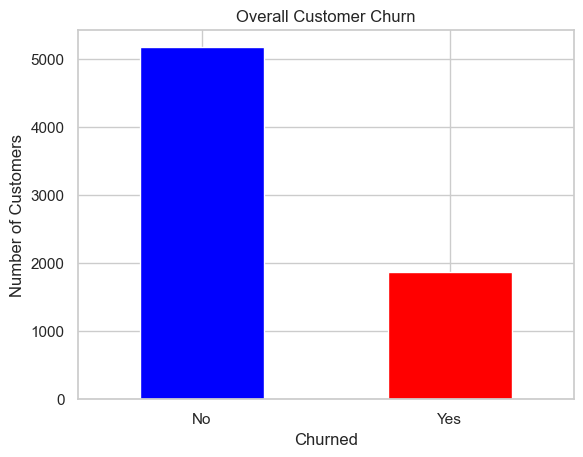

In [11]:
import matplotlib.pyplot as plt

churn_counts.plot(
    kind="bar",
    color=["blue", "red"]
)

plt.title("Overall Customer Churn")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

**Finding:**

Of the 7,043 customers, 1,869 churned. The overall churn rate was 26.54%,
meaning approximately one out of every four customers left the company.

### 5.2 Churn by Contract Type

Compare customer counts and churn rates across Month-to-Month, One-Year,
and Two-Year contracts.

In [12]:
contract_summary = (
    df.groupby("contract")["churn_value"]
    .agg(["count", "sum"])
    .reset_index()
)

contract_summary

,contract,count,sum
0,Month-to-Month,3610,1655
1,One Year,1550,166
2,Two Year,1883,48


In [13]:
contract_summary.columns = [
    "contract",
    "total_customers",
    "churned_customers"
]

contract_summary["churn_rate_pct"] = (
    contract_summary["churned_customers"]
    / contract_summary["total_customers"]
    * 100
).round(2)

contract_summary = contract_summary.sort_values(
    "churn_rate_pct",
    ascending=False
)

contract_summary

,contract,total_customers,churned_customers,churn_rate_pct
0,Month-to-Month,3610,1655,45.84
1,One Year,1550,166,10.71
2,Two Year,1883,48,2.55


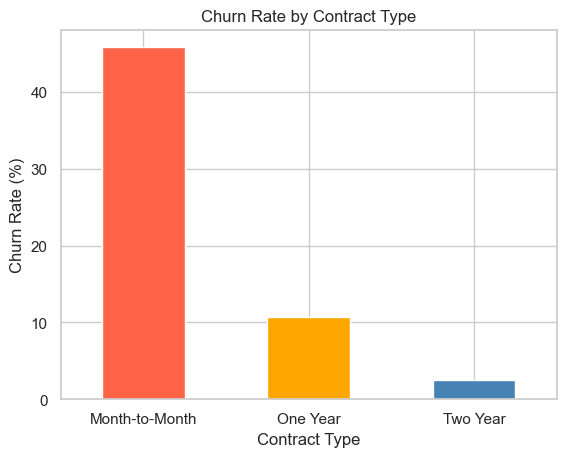

In [14]:
contract_summary.plot(
    kind="bar",
    x="contract",
    y="churn_rate_pct",
    color=["tomato", "orange", "steelblue"],
    legend=False
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

**Finding:**

Month-to-Month customers had the highest churn rate at 45.84%, compared
with 10.71% for One-Year and 2.55% for Two-Year contracts. Customers with
longer contracts were substantially less likely to churn.

### 5.3 Churn by Internet Type

Compare total customers, churned customers, and churn rates across the
different internet-service types.

In [15]:
internet_summary = (
    df.groupby("internet_type")["churn_value"]
    .agg(["count", "sum"])
    .reset_index()
)

internet_summary.columns = [
    "internet_type",
    "total_customers",
    "churned_customers"
]

internet_summary["churn_rate_pct"] = (
    internet_summary["churned_customers"]
    / internet_summary["total_customers"]
    * 100
).round(2)

internet_summary = internet_summary.sort_values(
    "churn_rate_pct",
    ascending=False
)

internet_summary

,internet_type,total_customers,churned_customers,churn_rate_pct
2,Fiber Optic,3035,1236,40.72
0,Cable,830,213,25.66
1,DSL,1652,307,18.58
3,None,1526,113,7.40


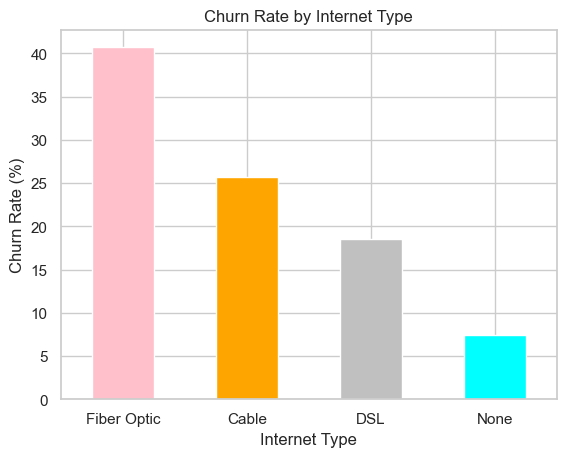

In [16]:
internet_summary.plot(
    kind="bar",
    x="internet_type",
    y="churn_rate_pct",
    color=["pink", "orange", "silver", "cyan"],
    legend=False
)

plt.title("Churn Rate by Internet Type")
plt.xlabel("Internet Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

**Finding:**

Fiber Optic customers had the highest churn rate at 40.72%, followed by
Cable at 25.66% and DSL at 18.58%. Customers without internet service had
the lowest churn rate at 7.40%.

Fiber Optic was associated with higher churn, but this does not prove that
the internet type directly caused customers to leave.

### 5.4 Churn by Customer Tenure

Group customers according to how many months they have used the company's
service, then compare churn rates across the customer-lifecycle stages.

In [17]:
tenure_bins = [0, 6, 12, 24, 48, float("inf")]

tenure_labels = [
    "0-6 months",
    "7-12 months",
    "13-24 months",
    "25-48 months",
    "49+ months"
]

df["tenure_group"] = pd.cut(
    df["tenure_in_months"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

In [18]:
df[["tenure_in_months", "tenure_group"]].head(10)

,tenure_in_months,tenure_group
0,69,49+ months
1,4,0-6 months
2,69,49+ months
3,15,13-24 months
4,11,7-12 months
5,43,25-48 months
6,58,49+ months
7,25,25-48 months
8,71,49+ months
9,54,49+ months


#### Tenure Group Summary

Calculate the number of customers and the churn rate within each tenure group.

In [19]:
tenure_summary = (
    df.groupby("tenure_group", observed=True)["churn_value"]
    .agg(["count", "sum"])
    .reset_index()
)

tenure_summary.columns = [
    "tenure_group",
    "total_customers",
    "churned_customers"
]

tenure_summary["churn_rate_pct"] = (
    tenure_summary["churned_customers"]
    / tenure_summary["total_customers"]
    * 100
).round(2)

tenure_summary

,tenure_group,total_customers,churned_customers,churn_rate_pct
0,0-6 months,1470,784,53.33
1,7-12 months,716,253,35.34
2,13-24 months,1024,294,28.71
3,25-48 months,1594,325,20.39
4,49+ months,2239,213,9.51


#### Churn Rate by Customer Tenure

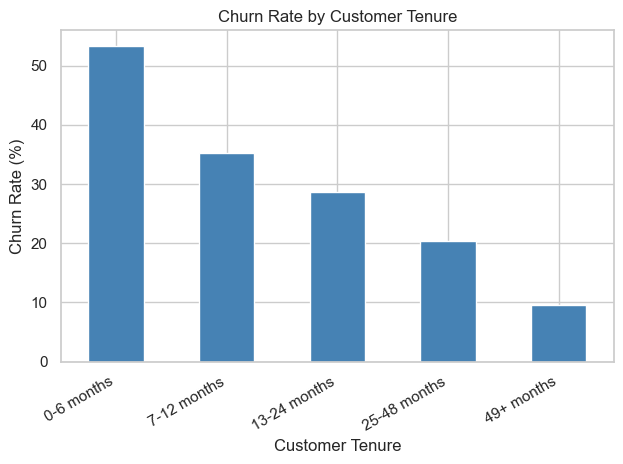

In [20]:
tenure_summary.plot(
    kind="bar",
    x="tenure_group",
    y="churn_rate_pct",
    color="steelblue",
    legend=False
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Finding:** Customers in their first 0–6 months had the highest churn rate at 53.33%. The churn rate consistently decreased as customer tenure increased, reaching only 9.51% among customers with 49 or more months of tenure. This suggests that customers are most at risk of leaving during the early stages of their relationship with the company.

### 5.5 Top Reasons for Customer Churn

Analyze only churned customers and identify their ten most frequently reported reasons for leaving.

In [21]:
churned_df = df[df["churn_value"] == 1]

top_churn_reasons = (
    churned_df["churn_reason"]
    .value_counts()
    .head(10)
)

top_churn_reasons

churn_reason
Competitor had better devices                313
Competitor made better offer                 311
Attitude of support person                   220
Don't know                                   130
Competitor offered more data                 117
Competitor offered higher download speeds    100
Attitude of service provider                  94
Price too high                                78
Product dissatisfaction                       77
Network reliability                           72
Name: count, dtype: int64

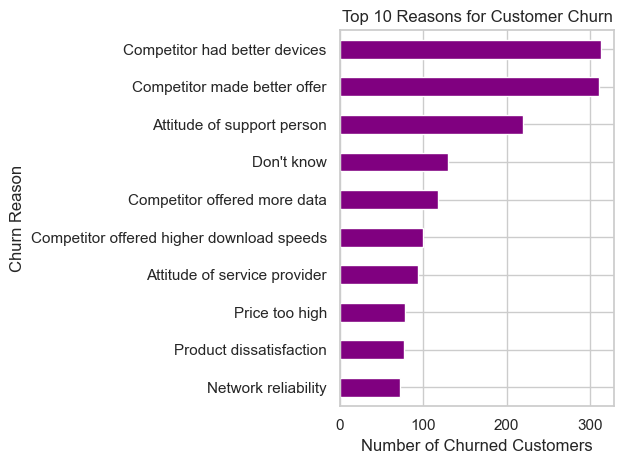

In [22]:
top_churn_reasons.sort_values().plot(
    kind="barh",
    color="purple"
)

plt.title("Top 10 Reasons for Customer Churn")
plt.xlabel("Number of Churned Customers")
plt.ylabel("Churn Reason")
plt.tight_layout()
plt.show()

**Finding:** Competitor-related issues were the strongest reasons for customer churn. “Competitor had better devices” was reported by 313 customers, while “Competitor made better offer” was reported by 311 customers. Together, these two reasons accounted for 624 churned customers, suggesting that the company should review its product offerings and competitive pricing.

## 6. Key Findings and Business Recommendations

### Key Findings

1. The company’s overall customer churn rate was **26.54%**, with 1,869 of 7,043 customers leaving.

2. Customers with **month-to-month contracts** had the highest churn rate at **45.84%**, compared with 10.71% for one-year contracts and 2.55% for two-year contracts.

3. **Fiber Optic customers** had the highest churn rate among internet-service groups at **40.72%**.

4. Customers in their first **0–6 months** had the highest tenure-based churn rate at **53.33%**. Churn consistently decreased as customer tenure increased.

5. Competitor-related issues were the strongest reported reasons for churn. Better competitor devices and better offers accounted for **624 churned customers**.

6.  Churned customers had an average monthly charge of **USD 74.44**, compared with **USD 61.27** for customers who did not churn.

### Business Recommendations

1. **Improve early customer support:** Introduce onboarding calls, service check-ins, and targeted offers during customers’ first six months.

2. **Encourage longer contracts:** Offer discounts or additional benefits to customers who move from month-to-month plans to one-year or two-year contracts.

3. **Review the Fiber Optic service:** Investigate its pricing, reliability, speed, and customer-support experience because Fiber Optic customers showed a high churn rate.

4. **Respond to competitor offers:** Review competitor pricing, devices, data allowances, and promotions to create more competitive retention offers.

5. **Monitor high-charge customers:** Identify customers paying above-average monthly charges and proactively check whether they are receiving sufficient value.

### Important Note

These results show associations between customer characteristics and churn, but they do not prove that any single factor directly caused customers to leave.

In [23]:
df.to_csv(
    "../data/processed/customer_churn_master.csv",
    index=False
)

In [24]:
df.shape

(7043, 52)